# The Mid-plane of the Main Asteroid Belt

#### This tutorial measures the plane about which the main-belt asteroids' orbits are scattered, using MPC orbits, and tests it against the warped plane predicted by classical secular perturbation theory.

Asteroid orbits are tilted in every direction by a few degrees, but not *around the ecliptic*: on average they are scattered around a slightly different plane, set by the gravity of the planets. [Cambioni & Malhotra (2018)](https://doi.org/10.3847/1538-3881/aaab6b) ([arXiv:1801.08096](https://arxiv.org/abs/1801.08096)) measured that plane from a large, nearly complete sample of asteroids and found an inclination of **0.93 ± 0.04°** and a longitude of ascending node of **87.6 ± 2.6°** relative to the J2000 ecliptic — distinct from both Jupiter's orbital plane and the Solar System's invariable plane. They then showed that the mid-plane is not flat: in narrow bins of semi-major axis it follows, for most of the belt, the *forced plane* of Laplace–Lagrange secular theory, which has a pronounced warp near the inner edge of the belt caused by the ν₁₆ secular resonance.

This notebook reproduces the core of that paper:

1. **Data.** The paper used the AstDyS-2 orbit catalogue; here the orbits come from the MPC's [`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html). The one ingredient the MPC does not provide is membership of collisional families, which the paper removes; for that we use the [AstDyS-2 family classification](https://newton.spacedys.com/astdys/index.php?pc=5), as the paper did.
2. **The mean plane** of the whole belt, with a bootstrap estimate of its uncertainty, following the paper's method step by step.
3. **Laplace–Lagrange secular theory**, built from scratch from the eight planets' orbits, to predict the forced plane as a function of semi-major axis.
4. **The warped mid-plane**: the measured mean plane in 0.1 AU bins against that prediction, and a 3-D view of the warp.

Nothing here is computationally heavy: after a one-time download of about 115 MB, the whole notebook runs in about a minute. It builds on the [Kirkwood gaps tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/) (for reading `MPCORB.DAT`) and the [reference frames tutorial](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_frames/) in the [Working with Orbits](https://docs.minorplanetcenter.net/tutorials/orbit_tutorials/) section.

## Environment Setup

This notebook requires `rebound`, `matplotlib`, `numpy`, and `requests`. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel so that all dependencies are isolated and reproducible.

Run the following commands once in a terminal before opening this notebook:

```bash
# Create and populate the environment
conda create -n orbit-tutorial python=3.11 -y
conda activate orbit-tutorial
pip install rebound mpc-orb astropy matplotlib numpy requests ipykernel

# Register the environment as a Jupyter kernel
python -m ipykernel install --user --name orbit-tutorial --display-name "Python (orbit-tutorial)"
```

If you do not already have a way of running Jupyter notebooks, also install Jupyter itself (`pip install jupyter`), then launch it from the directory containing this notebook with:

```bash
jupyter notebook
```

and open this file in the browser tab that appears. However you run the notebook, select **Kernel > Change Kernel > Python (orbit-tutorial)** before running the cells below.

If you already created the `orbit-tutorial` environment for the companion tutorials, you can simply reuse it — no new packages are needed.

# Install and Import Packages

We need `requests` to download the data, `numpy` and `matplotlib` for the analysis and the figures, and `rebound` to fetch the planets from JPL Horizons for the secular theory.

In [1]:
import os
import gzip
import time
import collections

import requests
import numpy as np
import matplotlib.pyplot as plt

import rebound

# Step 1: Download and Parse MPCORB

[`MPCORB.DAT`](https://minorplanetcenter.net/iau/MPCORB.html) holds the osculating orbit of every catalogued minor planet — about 1.5 million — in a fixed-width text format documented on the [Minor Planet Orbit Format page](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/). The elements are heliocentric and referred to the J2000 ecliptic and equinox, exactly the frame the paper works in.

We apply the paper's orbital cuts while reading, keeping only the main belt:

- semi-major axis 1.6 ≤ a ≤ 3.3 AU, and
- perihelion distance q = a(1 − e) ≥ 1.3 AU, which excludes near-Earth objects.

For each orbit we keep the semi-major axis, eccentricity, inclination, longitude of ascending node, absolute magnitude H, the packed epoch, and the designation in the form AstDyS uses (the number for numbered asteroids, the provisional designation without its space otherwise), so that we can look up family membership in Step 2. Almost the whole catalogue shares one standard epoch; we keep the orbits at that epoch so that every orbit plane is sampled at the same instant.

**Download note:** the cell caches `MPCORB.DAT.gz` (about 90 MB) in the notebook's working directory and only downloads it if it is not already present.

In [2]:
MPCORB_URL = "https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT.gz"
MPCORB_FILE = "MPCORB.DAT.gz"
A_MIN, A_MAX, Q_MIN = 1.6, 3.3, 1.3          # AU: the paper's main-belt selection

if not os.path.exists(MPCORB_FILE):
    print(f"Downloading {MPCORB_URL} (about 90 MB; this may take a few minutes)")
    with requests.get(MPCORB_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(MPCORB_FILE + ".part", "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
    os.rename(MPCORB_FILE + ".part", MPCORB_FILE)
    print("  done")
else:
    print(f"Using cached {MPCORB_FILE}")

# Fixed-width columns (1-indexed): H 9-13, epoch 21-25 (packed), Node 49-57, i 60-68, e 71-79,
# a 93-103, readable designation 167-194
cols = collections.defaultdict(list)
with gzip.open(MPCORB_FILE, "rt") as f:
    in_header = True
    for line in f:
        if in_header:                                  # header ends at a dashed line
            if line.startswith("----------"):
                in_header = False
            continue
        if len(line) < 194:                            # skip blank section separators
            continue
        try:
            a_, e_ = float(line[92:103]), float(line[70:79])
            if not (A_MIN <= a_ <= A_MAX and a_ * (1 - e_) >= Q_MIN):
                continue
            H_, i_, node_ = float(line[8:13]), float(line[59:68]), float(line[48:57])
        except ValueError:                             # missing elements or missing H
            continue
        readable = line[166:194].strip()               # "(4) Vesta" or "2008 BQ27"
        name = readable[1:readable.index(")")] if readable.startswith("(") else readable.replace(" ", "")
        for key, val in (("a", a_), ("e", e_), ("inc", i_), ("node", node_), ("H", H_),
                         ("epoch", line[20:25]), ("name", name)):
            cols[key].append(val)

epoch_mode = collections.Counter(cols["epoch"]).most_common(1)[0][0]
keep = np.array(cols["epoch"]) == epoch_mode
a, e, inc, node, H = (np.array(cols[k])[keep] for k in ("a", "e", "inc", "node", "H"))
names = np.array(cols["name"])[keep]
del cols
print(f"{len(a):,} main-belt orbits at the common epoch {epoch_mode!r}")

Using cached MPCORB.DAT.gz


1,469,629 main-belt orbits at the common epoch 'K2669'


# Step 2: A Fair Sample — Completeness and Collisional Families

The mean plane of the belt should be measured from a sample that represents the belt's orbit planes without bias. The paper identifies two biases and removes both.

**Observational incompleteness.** Bright asteroids are easier to find than faint ones. For a population whose numbers rise steeply toward small sizes, the histogram of absolute magnitude H should keep rising; where it flattens and turns over (left panel below) the catalogue stops being complete. In the 2017 catalogue the paper used, the turnover was near H ≈ 16, and the paper kept H < 15.5, half a magnitude brighter. The surveys have gone deeper since — today the turnover is near H ≈ 17.5 — but we keep the paper's cut so as to reproduce its sample, and test fainter cuts below.

**Collisional families.** A family is a swarm of fragments from one collision. Its members start with nearly identical orbit planes, so a big family counts as thousands of correlated votes for one plane. The paper removes every family member except the family's "mother", its largest or brightest member. We do the same with the current [AstDyS-2 family classification](https://newton.spacedys.com/astdys/index.php?pc=5) (Milani et al. 2014 and updates), whose membership file lists every family member with the family it belongs to. We keep the brightest member of each family and drop the rest.

**Download note:** the membership file is about 25 MB and is cached like `MPCORB.DAT.gz`.

In [3]:
H_CUT = 15.5
FAMILY_URL = "https://newton.spacedys.com/~astdys2/propsynth/all_tro.members"
FAMILY_FILE = "astdys_all_tro.members"

if not os.path.exists(FAMILY_FILE):
    print(f"Downloading {FAMILY_URL} (about 25 MB)")
    r = requests.get(FAMILY_URL, timeout=600)
    r.raise_for_status()
    with open(FAMILY_FILE, "wb") as f:
        f.write(r.content)
    print(f"  done; AstDyS last modified {r.headers.get('Last-Modified', 'unknown')}")
else:
    print(f"Using cached {FAMILY_FILE}")

# Columns: name, H, status, family, ... (lines starting with % are headers)
family_of, brightest = {}, {}
with open(FAMILY_FILE) as f:
    for line in f:
        if line.startswith("%"):
            continue
        name, H_fam, _, fam = line.split()[:4]
        family_of[name] = fam
        if fam not in brightest or float(H_fam) < brightest[fam][1]:
            brightest[fam] = (name, float(H_fam))
mothers = {name for name, _ in brightest.values()}
print(f"{len(family_of):,} family members in {len(brightest)} families; the brightest member of each is kept")

in_family = np.array([(nm in family_of) and (nm not in mothers) for nm in names])
bright = H < H_CUT
sample = bright & ~in_family
print(f"H < {H_CUT}: {bright.sum():,} asteroids, of which {np.sum(bright & in_family):,} are family members;"
      f" the pared sample has {sample.sum():,}")

Using cached astdys_all_tro.members


264,559 family members in 117 families; the brightest member of each is kept


H < 15.5: 107,524 asteroids, of which 33,469 are family members; the pared sample has 74,055


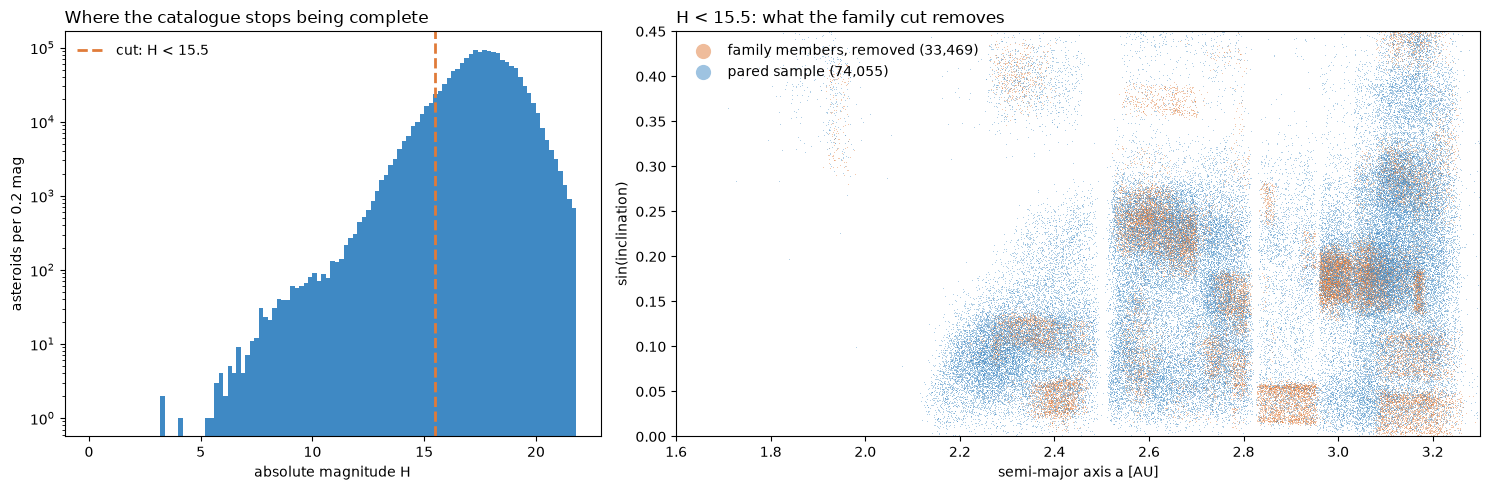

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.5]})

ax1.hist(H, bins=np.arange(0, 22, 0.2), color="#3f89c4", lw=0)
ax1.axvline(H_CUT, color="#e07b39", lw=2, ls="--", label=f"cut: H < {H_CUT}")
ax1.set_yscale("log")
ax1.set_xlabel("absolute magnitude H"); ax1.set_ylabel("asteroids per 0.2 mag")
ax1.set_title("Where the catalogue stops being complete", loc="left")
ax1.legend(frameon=False)

sel_f, sel_b = bright & in_family, sample
ax2.scatter(a[sel_f], np.sin(np.radians(inc[sel_f])), s=0.3, color="#e07b39", lw=0, alpha=0.5,
            label=f"family members, removed ({sel_f.sum():,})", rasterized=True)
ax2.scatter(a[sel_b], np.sin(np.radians(inc[sel_b])), s=0.3, color="#3f89c4", lw=0, alpha=0.5,
            label=f"pared sample ({sel_b.sum():,})", rasterized=True)
ax2.set_xlim(A_MIN, A_MAX); ax2.set_ylim(0, 0.45)
ax2.set_xlabel("semi-major axis a [AU]"); ax2.set_ylabel("sin(inclination)")
ax2.set_title(f"H < {H_CUT}: what the family cut removes", loc="left")
ax2.legend(frameon=False, markerscale=20, loc="upper left")
plt.tight_layout(); plt.show()

The families show up as dense, tight clumps in the right-hand panel: the Vesta family near 2.35 AU and sin i ≈ 0.11, Nysa–Polana just below it, Eunomia near 2.65 AU and sin i ≈ 0.23, Koronis between 2.83 and 2.95 AU at low inclination, Eos near 3.0 AU and sin i ≈ 0.17, Themis near 3.15 AU at low inclination, and many more. Removing them takes out 31% of the bright asteroids.

# Step 3: The Mean Plane

The pole of an orbit — the unit vector perpendicular to its plane — has components, in the J2000 ecliptic frame,

```
n = (sin I sin Ω,  −sin I cos Ω,  cos I)
```

where I is the ecliptic inclination and Ω the longitude of the ascending node. The paper's mean plane is simply the plane whose pole is the **average of the N unit poles**, normalized back to unit length. Its inclination and node follow from the components of that mean pole:

```
Ī = arccos(n̄₃),    Ω̄ = atan2(n̄₁, −n̄₂)
```

Because every asteroid gets one vote, the precision is set by the scatter of the poles and the size of the sample: about 75,000 poles with an rms scatter of about 12° about their mean (Plummer found 11.2° from 753 asteroids in 1916) fix the mean pole to about 12°/√75,000 ≈ 0.04°.

### The uncertainty

The paper estimates the uncertainty by **bootstrapping**: draw N poles at random *with replacement* from the sample, compute the mean pole of that resampled set, and repeat 10,000 times. The spread of the bootstrapped mean poles is the measurement uncertainty. The paper projects them onto the ecliptic as the "inclination-vector" components

```
Q = sin I cos Ω,    P = sin I sin Ω
```

draws the contour enclosing 68.3% of them, and reads off the largest and smallest inclination and node on that contour as the 1-σ range. We do the same, with the contour taken as the 68.3% ellipse of the bootstrap distribution. (For a two-dimensional Gaussian that ellipse lies √2.30 ≈ 1.5 standard deviations from the centre, so it is a slightly conservative error bar.)

`bootstrap_QP` draws each resample as a vector of counts with `np.bincount`, so that the resampled mean is a single matrix–vector product. Ten thousand resamples of 75,000 poles take a few seconds.

In [5]:
def orbit_poles(inc_deg, node_deg):
    I, O = np.radians(inc_deg), np.radians(node_deg)
    return np.column_stack([np.sin(I) * np.sin(O), -np.sin(I) * np.cos(O), np.cos(I)])

def mean_plane(poles):
    v = poles.mean(axis=0)
    v /= np.linalg.norm(v)
    return np.degrees(np.arccos(v[2])), np.degrees(np.arctan2(v[0], -v[1])) % 360

def bootstrap_QP(poles, n_boot=10_000, seed=1):
    # (Q, P) = (sin I cos Omega, sin I sin Omega) of n_boot bootstrapped mean poles
    rng = np.random.default_rng(seed)
    N = len(poles)
    out = np.empty((n_boot, 2))
    for b in range(n_boot):
        v = np.bincount(rng.integers(0, N, N), minlength=N) @ poles
        v /= np.linalg.norm(v)
        out[b] = (-v[1], v[0])
    return out

CHI2_2D = {1: 2.30, 2: 6.18, 3: 11.83}   # 2-D Gaussian: ellipses enclosing 68.3, 95.4, 99.7%

def contour(QP, n_sigma):
    L = np.linalg.cholesky(np.cov(QP.T))
    t = np.linspace(0, 2 * np.pi, 721)
    return QP.mean(axis=0) + np.sqrt(CHI2_2D[n_sigma]) * (L @ np.vstack([np.cos(t), np.sin(t)])).T

def plane_errors(QP, I_bar, O_bar):
    # the paper's recipe: extreme inclination and node on the 1-sigma contour
    c = contour(QP, 1)
    I_c = np.degrees(np.arcsin(np.hypot(c[:, 0], c[:, 1])))
    dO = (np.degrees(np.arctan2(c[:, 1], c[:, 0])) - O_bar + 180) % 360 - 180
    return I_c.max() - I_bar, I_bar - I_c.min(), dO.max(), -dO.min()

def measure(selection, n_boot=10_000):
    p = orbit_poles(inc[selection], node[selection])
    I_bar, O_bar = mean_plane(p)
    QP = bootstrap_QP(p, n_boot)
    return {"N": len(p), "I": I_bar, "O": O_bar, "QP": QP, "err": plane_errors(QP, I_bar, O_bar)}

def show(label, r):
    sIp, sIm, sOp, sOm = r["err"]
    print(f"{label:<32} N = {r['N']:>7,}   I = {r['I']:.3f} +{sIp:.3f}/-{sIm:.3f} deg   "
          f"Omega = {r['O']:6.2f} +{sOp:.2f}/-{sOm:.2f} deg")

tic = time.time()
result = measure(sample)
p_all = orbit_poles(inc[sample], node[sample])
m_all = p_all.mean(axis=0) / np.linalg.norm(p_all.mean(axis=0))
scatter = np.degrees(np.arccos(np.clip(p_all @ m_all, -1, 1)))
print(f"rms scatter of the {len(p_all):,} poles about their mean: {np.sqrt(np.mean(scatter**2)):.1f} deg\n")
show(f"pared sample (H < {H_CUT})", result)
print(f"{'Cambioni & Malhotra (2018)':<32} N =  89,216   I = 0.93 +- 0.04 deg          Omega =  87.6 +- 2.6 deg")
print(f"\n(10,000 bootstrap resamples in {time.time() - tic:.0f} s)")

rms scatter of the 74,055 poles about their mean: 12.1 deg

pared sample (H < 15.5)          N =  74,055   I = 0.955 +0.048/-0.048 deg   Omega =  90.62 +2.88/-2.89 deg
Cambioni & Malhotra (2018)       N =  89,216   I = 0.93 +- 0.04 deg          Omega =  87.6 +- 2.6 deg

(10,000 bootstrap resamples in 6 s)


### How sensitive is the answer to the choices?

The paper checked that its result does not depend on the magnitude cut, and argued that families must be removed. Both are quick to test here, with fewer bootstrap resamples:

In [6]:
show("families kept (H < 15.5)", measure(bright, n_boot=2000))
for h in (14.5, 15.0, 16.0):
    show(f"families removed, H < {h}", measure((H < h) & ~in_family, n_boot=2000))

families kept (H < 15.5)         N = 107,524   I = 0.993 +0.039/-0.041 deg   Omega =  91.24 +2.24/-2.25 deg


families removed, H < 14.5       N =  21,897   I = 0.852 +0.092/-0.093 deg   Omega =  91.07 +6.33/-6.31 deg


families removed, H < 15.0       N =  41,038   I = 0.900 +0.066/-0.064 deg   Omega =  91.16 +4.16/-4.19 deg


families removed, H < 16.0       N = 128,381   I = 0.983 +0.037/-0.038 deg   Omega =  90.58 +2.12/-2.15 deg


Keeping the families moves the answer by less than one standard error — for the belt as a whole, old families have had time for their members' nodes to precess apart, so they add noise rather than bias. The magnitude cut matters a little more: the inclination creeps up by about 0.13° from H < 14.5 to H < 16. Each step is within about one standard error of the next, and the paper made the same check with the same conclusion (its cuts from H < 14.5 to H < 16 agree within 3σ), but the trend is worth keeping in mind when comparing measurements made with different cuts.

Our pared sample is smaller than the paper's, though MPCORB contains more asteroids today than AstDyS did in 2017. The reason is the family list: the classification has grown since 2017 and now attributes more asteroids to families, so more are removed.

### The mean pole on the sky

Now the picture corresponding to the paper's Figure 4: the ten thousand bootstrapped mean poles in the (Q, P) plane, with their 1-, 2- and 3-σ contours. The ecliptic pole is at the origin, below the frame: the whole picture is a region about 1° across, 1° from the ecliptic pole. For comparison we mark the paper's measurement, the pole of Jupiter's orbit (from JPL Horizons, below), and the pole of the Solar System's **invariable plane** — the plane perpendicular to its total angular momentum, which is dominated by Jupiter and Saturn ([Souami & Souchay 2012](https://doi.org/10.1051/0004-6361/201219011): I = 1.578694°, Ω = 107.582222°). The belt's mid-plane is clearly distinct from both. It is also distinct from the older estimates by [Plummer (1916)](https://doi.org/10.1093/mnras/76.5.378), from 753 asteroids, and by Shor & Yagudina (1992); the paper attributes their offsets to family members and incompleteness in those smaller samples.

Searching NASA Horizons for 'Sun'... 


Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 


Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 


Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 


Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 


Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 


Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 


Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 


Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Planets from JPL Horizons at 2026-06-09; Jupiter: I = 1.304 deg, Omega = 100.52 deg


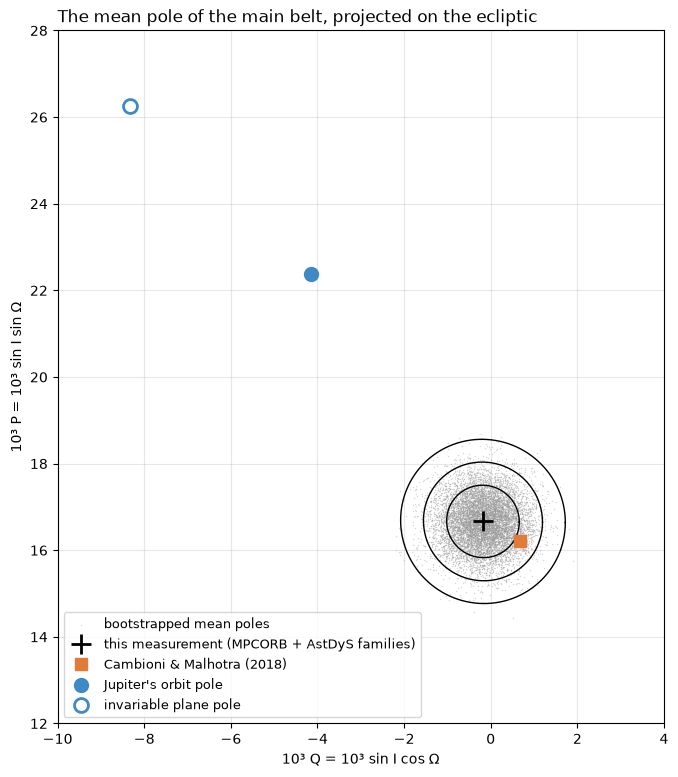

In [7]:
def to_QP(I_deg, O_deg):
    I, O = np.radians(I_deg), np.radians(O_deg)
    return np.sin(I) * np.cos(O), np.sin(I) * np.sin(O)

# Planets at the catalogue epoch (also used by the secular theory in Step 4)
def unpack_epoch(packed):
    century = {"I": 18, "J": 19, "K": 20}[packed[0]]
    year = century * 100 + int(packed[1:3])
    month = int(packed[3], 36) if packed[3].isdigit() else ord(packed[3]) - 55
    day = int(packed[4], 36) if packed[4].isdigit() else ord(packed[4]) - 55
    return f"{year:04d}-{month:02d}-{day:02d}"

epoch_date = unpack_epoch(epoch_mode)
PLANETS = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"]
sim = rebound.Simulation()
sim.units = ("AU", "yr", "Msun")
for body in ["Sun"] + PLANETS:                  # "Earth" resolves to the Earth-Moon barycentre
    sim.add(body, date=f"{epoch_date} 00:00")
sun = sim.particles[0]
planet_orbits = [sim.particles[k].orbit(primary=sun) for k in range(1, 9)]
I_jup, O_jup = np.degrees(planet_orbits[4].inc), np.degrees(planet_orbits[4].Omega)
print(f"Planets from JPL Horizons at {epoch_date}; Jupiter: I = {I_jup:.3f} deg, Omega = {O_jup:.2f} deg")

fig, ax = plt.subplots(figsize=(8, 9))
QP = result["QP"] * 1e3
ax.scatter(QP[:, 0], QP[:, 1], s=1, color="#999999", alpha=0.4, lw=0, label="bootstrapped mean poles")
for k in (1, 2, 3):
    c = contour(result["QP"], k) * 1e3
    ax.plot(c[:, 0], c[:, 1], color="black", lw=1)
ax.plot(*(np.array(to_QP(result["I"], result["O"])) * 1e3), "k+", ms=14, mew=2, label="this measurement (MPCORB + AstDyS families)")
ax.plot(*(np.array(to_QP(0.93, 87.6)) * 1e3), "s", color="#e07b39", ms=9, label="Cambioni & Malhotra (2018)")
ax.plot(*(np.array(to_QP(I_jup, O_jup)) * 1e3), "o", color="#3f89c4", ms=10, label="Jupiter's orbit pole")
ax.plot(*(np.array(to_QP(1.578694, 107.582222)) * 1e3), "o", mfc="none", mec="#3f89c4", mew=2, ms=10,
        label="invariable plane pole")
ax.set_aspect("equal")
ax.set_xlabel("10³ Q = 10³ sin I cos Ω"); ax.set_ylabel("10³ P = 10³ sin I sin Ω")
ax.set_xlim(-10, 4); ax.set_ylim(12, 28)
ax.set_title("The mean pole of the main belt, projected on the ecliptic", loc="left")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

# Step 4: The Forced Plane from Secular Theory

Why should the belt have a mid-plane that is neither the ecliptic nor Jupiter's orbit? Over tens of thousands of years, the planets' gravity makes every asteroid's orbit plane precess. In **Laplace–Lagrange secular theory** (Murray & Dermott 1999, chapter 7) an asteroid's inclination vector — its (Q, P) — is the sum of two parts:

- a **free** (or proper) inclination vector, whose length is set by the asteroid's history and whose direction circulates at the asteroid's own nodal precession rate f₀, and
- a **forced** inclination vector, set entirely by the planets, which depends only on the asteroid's semi-major axis.

Averaged over a population with circulating free vectors, only the forced part survives. So the mean plane at a given semi-major axis should be the **forced plane**.

The planets' own orbit planes also precess, as a superposition of eight modes. Each mode i has a frequency fᵢ, a phase γᵢ and a fixed pattern of amplitudes across the planets. The forced inclination of a test particle at semi-major axis a is

```
(sin I₀ cos Ω₀, sin I₀ sin Ω₀) = Σᵢ  μᵢ / (fᵢ − f₀) · (cos γᵢ, sin γᵢ)
```

where f₀(a) and μᵢ(a) come from the same Laplace coefficients that couple the planets. A glance at the denominator shows what to expect: wherever the asteroid's precession rate f₀ matches one of the planetary frequencies fᵢ, the forced inclination blows up. That is a **secular resonance**. In the main belt the relevant one is **ν₁₆**, where f₀ equals the fastest planetary nodal frequency f₆ (about −26″/yr), which is dominated by Jupiter and Saturn. It sits near 1.95 AU, just inside the belt's inner edge, and warps the forced plane there.

The code below builds the theory directly:

1. the 8 × 8 matrix **B** of secular coupling coefficients, from the planets' masses and semi-major axes and the Laplace coefficient b⁽¹⁾₃/₂;
2. its eigenvalues (the frequencies fᵢ) and eigenvectors;
3. the amplitudes and phases of each mode, fitted to the planets' current inclinations and nodes from JPL Horizons;
4. the forced plane for a test particle at any semi-major axis.

The Laplace coefficient is an integral over a full period of a smooth function, so a plain average over evenly spaced points is extremely accurate (spectrally accurate), and no special-purpose integration library is needed.

In [8]:
GM_SUN = sim.G * sun.m                                        # AU^3 / yr^2
a_pl = np.array([o.a for o in planet_orbits])
m_pl = np.array([sim.particles[k].m for k in range(1, 9)]) / sun.m      # in solar masses
I_pl = np.array([o.inc for o in planet_orbits])
O_pl = np.array([o.Omega for o in planet_orbits])
n_pl = np.sqrt(GM_SUN * (1 + m_pl) / a_pl**3)                 # mean motions, rad / yr

PSI = np.linspace(0, 2 * np.pi, 4096, endpoint=False)
def laplace_b32_1(alpha):
    # Laplace coefficient b^(1)_{3/2}(alpha) = (1/pi) * integral over 0..2pi of cos(psi) / (1 - 2 alpha cos psi + alpha^2)^(3/2)
    alpha = np.atleast_1d(alpha)[:, None]
    return 2.0 * np.mean(np.cos(PSI) / (1 - 2 * alpha * np.cos(PSI) + alpha**2) ** 1.5, axis=1)

def coupling(a_body, a_perturber):
    # alpha * alpha_bar * b^(1)_{3/2}(alpha) for a body perturbed by another (Murray & Dermott, ch. 7)
    alpha = np.minimum(a_body, a_perturber) / np.maximum(a_body, a_perturber)
    alpha_bar = np.where(a_perturber > a_body, alpha, 1.0)     # 1 for an interior perturber
    return (alpha * alpha_bar * laplace_b32_1(alpha.ravel()).reshape(alpha.shape))

# 1. the planets' secular matrix B
with np.errstate(divide="ignore", invalid="ignore"):     # the diagonal (a planet on itself) is unused
    C = coupling(a_pl[:, None], a_pl[None, :])
np.fill_diagonal(C, 0.0)
B = 0.25 * n_pl[:, None] * m_pl[None, :] / (1 + m_pl[:, None]) * C
B[np.diag_indices(8)] = -B.sum(axis=1)

# 2. eigenfrequencies f_i and eigenvectors
f_modes, V = np.linalg.eig(B)
f_modes, V = f_modes.real, V.real

# 3. amplitudes and phases from the planets' present-day inclination vectors
p_now, q_now = np.sin(I_pl) * np.sin(O_pl), np.sin(I_pl) * np.cos(O_pl)
S_amp, C_amp = np.linalg.solve(V, p_now), np.linalg.solve(V, q_now)
gamma = np.arctan2(S_amp, C_amp)
I_ji = V * np.hypot(S_amp, C_amp)[None, :]                  # amplitude of mode i in planet j

# Label the modes f1..f8 by matching to the values tabulated by Murray & Dermott (1999), arcsec / yr
MD_FREQS = [-5.20, -6.57, -18.74, -17.63, 0.00, -25.73, -2.90, -0.68]
f_arcsec = np.degrees(f_modes) * 3600
label_of = {i: int(np.argmin(np.abs(np.array(MD_FREQS) - f))) + 1 for i, f in enumerate(f_arcsec)}
print("mode   this notebook   Murray & Dermott   [arcsec/yr]")
for i in sorted(label_of, key=label_of.get):
    print(f"  f{label_of[i]}   {f_arcsec[i]:10.2f}      {MD_FREQS[label_of[i] - 1]:10.2f}")

# 4. the forced plane of a test particle
def forced_plane(a_tp):
    a_tp = np.atleast_1d(a_tp).astype(float)
    n_tp = np.sqrt(GM_SUN / a_tp**3)
    Bj = 0.25 * n_tp[:, None] * m_pl[None, :] * coupling(a_tp[:, None], a_pl[None, :])
    f0 = -Bj.sum(axis=1)                                      # the particle's own nodal precession rate
    mu = Bj @ I_ji
    w = mu / (f_modes[None, :] - f0[:, None])
    q0, p0 = (w * np.cos(gamma)).sum(axis=1), (w * np.sin(gamma)).sum(axis=1)
    sin_I0 = np.clip(np.hypot(q0, p0), 0, 1)                  # saturates only right at the resonance
    return np.degrees(np.arcsin(sin_I0)), np.degrees(np.arctan2(p0, q0)), np.degrees(f0) * 3600

a_grid = np.linspace(1.6, 3.4, 1801)
I_forced, O_forced, f0_grid = forced_plane(a_grid)
f6 = f_arcsec[[i for i in label_of if label_of[i] == 6][0]]
a_nu16 = a_grid[np.argmin(np.abs(f0_grid - f6))]
print(f"\nnu16 secular resonance (f0 = f6 = {f6:.2f} arcsec/yr) at a = {a_nu16:.3f} AU")
print(f"forced plane at 3.3 AU: I = {forced_plane(3.3)[0][0]:.3f} deg, Omega = {forced_plane(3.3)[1][0] % 360:.2f} deg"
      f"   (Jupiter: I = {I_jup:.3f}, Omega = {O_jup:.2f})")

mode   this notebook   Murray & Dermott   [arcsec/yr]
  f1        -5.20           -5.20
  f2        -6.57           -6.57
  f3       -18.75          -18.74
  f4       -17.64          -17.63
  f5         0.00            0.00
  f6       -25.92          -25.73
  f7        -2.87           -2.90
  f8        -0.68           -0.68



nu16 secular resonance (f0 = f6 = -25.92 arcsec/yr) at a = 1.950 AU
forced plane at 3.3 AU: I = 1.236 deg, Omega = 98.91 deg   (Jupiter: I = 1.304, Omega = 100.52)


The eight frequencies agree with the published values to a fraction of an arcsecond per year. The ν₁₆ resonance falls just inside the inner edge of the belt. Further out, the forced plane approaches Jupiter's orbit plane, as the theory says it must: at a planet's own semi-major axis the forced plane coincides with the planet's orbit.

# Step 5: The Warped Mid-plane

The test of the theory is to measure the mean plane locally. Following the paper, we divide the pared sample into 0.1 AU bins of semi-major axis from 2.1 to 3.3 AU, plus one wide bin from 1.7 to 2.1 AU, where there are too few asteroids to split. We measure each bin's mean plane with the same method as in Step 3, using 2,000 bootstrap resamples per bin, and compare it with the forced plane at the bin's centre. The printout gives the significance of each difference the way the paper judges it (its Figures 6–8): the forced pole is inside the measured pole's 1-, 2- or 3-σ bootstrap contour, or outside all three. The figure after it is the paper's Figure 5.

In [9]:
bins = [(1.7, 2.1)] + [(round(x, 1), round(x + 0.1, 1)) for x in np.arange(2.1, 3.3 - 1e-9, 0.1)]
def sigma_level(QP, I0, O0):
    # which bootstrap contour (1, 2, 3 sigma) of the measured pole contains the forced pole
    d = np.array(to_QP(I0, O0)) - QP.mean(axis=0)
    d2 = d @ np.linalg.solve(np.cov(QP.T), d)
    return next((f"within {k} sigma" for k in (1, 2, 3) if d2 <= CHI2_2D[k]), "beyond 3 sigma")

binned = []
for lo, hi in bins:
    r = measure(sample & (a >= lo) & (a < hi), n_boot=2000)
    r["lo"], r["hi"] = lo, hi
    binned.append(r)
    I0, O0, _ = forced_plane(0.5 * (lo + hi))
    print(f"{lo:.1f}-{hi:.1f} AU  N = {r['N']:>6,}   I = {r['I']:5.2f} (forced {I0[0]:5.2f})   "
          f"Omega = {r['O']:6.1f} (forced {O0[0] % 360:6.1f}) deg   forced pole {sigma_level(r['QP'], I0[0], O0[0])}")

1.7-2.1 AU  N =    343   I =  1.53 (forced  7.72)   Omega =  116.2 (forced  122.4) deg   forced pole beyond 3 sigma
2.1-2.2 AU  N =  1,009   I =  0.75 (forced  0.66)   Omega =   59.5 (forced   11.8) deg   forced pole beyond 3 sigma
2.2-2.3 AU  N =  4,903   I =  0.63 (forced  0.65)   Omega =   71.5 (forced   61.4) deg   forced pole within 2 sigma


2.3-2.4 AU  N =  5,274   I =  0.78 (forced  0.80)   Omega =   76.3 (forced   79.6) deg   forced pole within 1 sigma
2.4-2.5 AU  N =  3,774   I =  0.84 (forced  0.92)   Omega =   87.6 (forced   87.2) deg   forced pole within 1 sigma
2.5-2.6 AU  N =  6,645   I =  0.88 (forced  1.00)   Omega =   97.4 (forced   91.2) deg   forced pole within 2 sigma


2.6-2.7 AU  N =  8,475   I =  1.00 (forced  1.06)   Omega =   89.2 (forced   93.6) deg   forced pole within 1 sigma
2.7-2.8 AU  N =  8,050   I =  1.09 (forced  1.11)   Omega =   96.9 (forced   95.2) deg   forced pole within 1 sigma
2.8-2.9 AU  N =  2,385   I =  1.03 (forced  1.14)   Omega =   96.6 (forced   96.3) deg   forced pole within 1 sigma


2.9-3.0 AU  N =  3,775   I =  1.19 (forced  1.17)   Omega =   83.7 (forced   97.2) deg   forced pole within 2 sigma
3.0-3.1 AU  N = 10,296   I =  0.98 (forced  1.19)   Omega =   99.8 (forced   97.8) deg   forced pole within 3 sigma


3.1-3.2 AU  N = 15,123   I =  1.01 (forced  1.21)   Omega =   89.6 (forced   98.3) deg   forced pole within 3 sigma
3.2-3.3 AU  N =  4,003   I =  1.11 (forced  1.23)   Omega =   89.6 (forced   98.7) deg   forced pole within 1 sigma


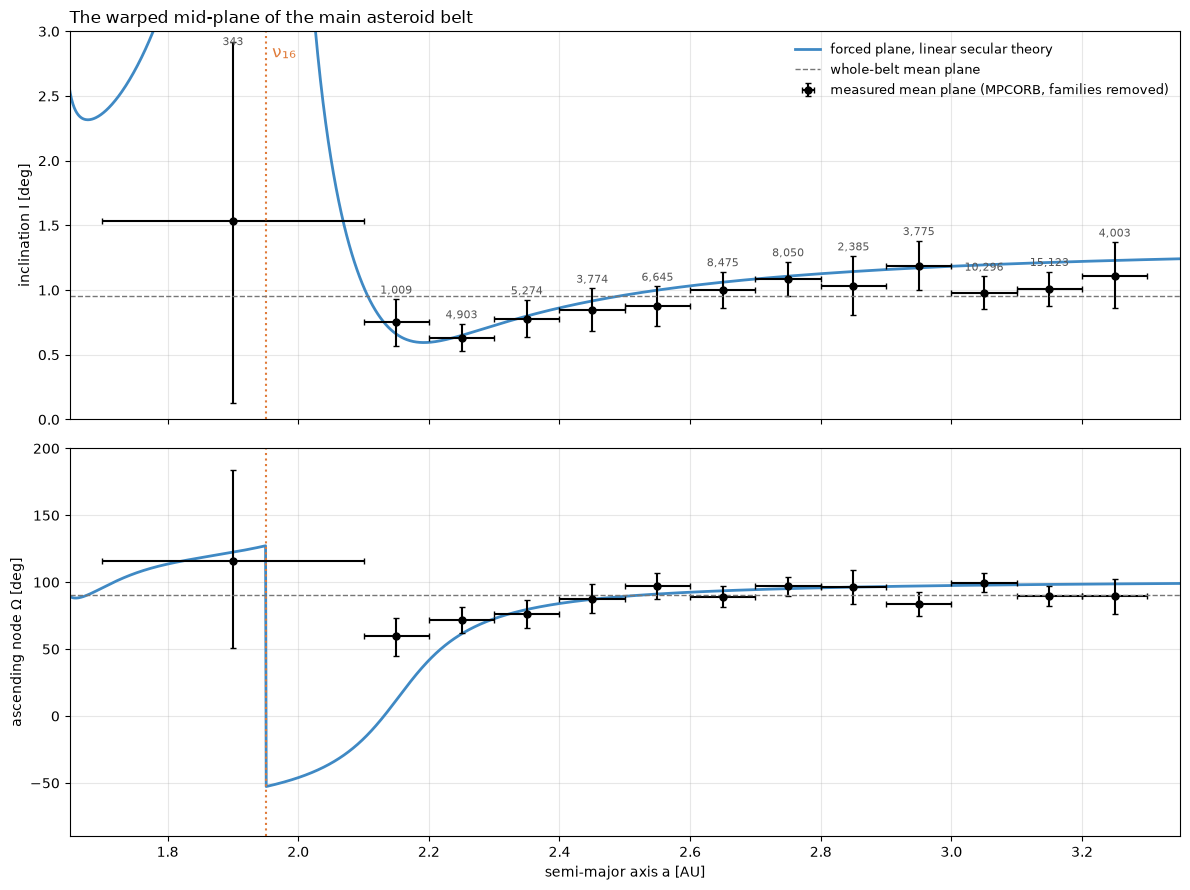

In [10]:
def wrap(O_deg):                        # display nodes in (-90, 270] degrees
    return (np.asarray(O_deg) + 90) % 360 - 90

centres = np.array([0.5 * (r["lo"] + r["hi"]) for r in binned])
halfw = np.array([0.5 * (r["hi"] - r["lo"]) for r in binned])
I_m = np.array([r["I"] for r in binned])
O_m = wrap([r["O"] for r in binned])
err = np.array([r["err"] for r in binned])            # +I, -I, +Omega, -Omega

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for ax, y, ylo, yhi, curve, lab in ((ax1, I_m, err[:, 1], err[:, 0], I_forced, "inclination I [deg]"),
                                    (ax2, O_m, err[:, 3], err[:, 2], wrap(O_forced), "ascending node Ω [deg]")):
    ax.plot(a_grid, curve, color="#3f89c4", lw=2, label="forced plane, linear secular theory")
    ax.errorbar(centres, y, yerr=[ylo, yhi], xerr=halfw, fmt="o", color="black", ms=5, capsize=2,
                label="measured mean plane (MPCORB, families removed)")
    ax.axvline(a_nu16, color="#e07b39", ls=":", lw=1.5)
    ax.set_ylabel(lab); ax.grid(alpha=0.3)
for x, y, up, r in zip(centres, I_m, err[:, 0], binned):
    ax1.annotate(f"{r['N']:,}", (x, min(y + up, 2.85)), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8, color="#555555")
ax1.text(a_nu16 + 0.01, 2.8, "ν₁₆", color="#e07b39", fontsize=12)
ax1.axhline(result["I"], color="#777777", ls="--", lw=1, label="whole-belt mean plane")
ax2.axhline(wrap(result["O"]), color="#777777", ls="--", lw=1)
ax1.set_ylim(0, 3); ax2.set_ylim(-90, 200)
ax2.set_xlim(1.65, 3.35); ax2.set_xlabel("semi-major axis a [AU]")
ax1.set_title("The warped mid-plane of the main asteroid belt", loc="left")
ax1.legend(loc="upper right", fontsize=9, frameon=False)
plt.tight_layout(); plt.show()

### Reading the figure

From 2.2 to 2.9 AU the forced pole lies within 2σ of the measured pole in every bin: the measured mid-plane reaches its lowest inclination near 2.2 AU and swings its node from about 70° to about 95°, as the theory predicts. Three features match what the paper found:

- **The outer belt agrees less well.** Between 2.9 and 3.3 AU every bin is within 3σ, but the 3.0–3.1 and 3.1–3.2 AU bins only just, with inclinations about 0.2° below the prediction. The paper found its largest outer-belt deviation in the same place, the bin centred on 3.15 AU, next to the 2:1 resonance with Jupiter, where linear secular theory is not valid. More generally, the measured inclination sits slightly below the theory through most of the middle and outer belt. The paper saw the same small offset and could not establish it statistically with the 2017 sample; it suggested that roughly ten times more asteroids, as the Rubin Observatory's LSST should deliver, would settle the question.
- **The 2.1–2.2 AU bin disagrees with the theory by more than 3σ**, almost entirely in its node. It lies close to the ν₁₆ and ν₆ secular resonances and the 4:1 mean-motion resonance with Jupiter, where *linear* secular theory does not hold. The paper found this the most significant deviation of all.
- **The few hundred asteroids inside 2.1 AU are not a fair test.** They are highly inclined, and the forced plane changes so fast across this bin, which contains the ν₁₆ resonance itself, that its value at the bin centre means little. The paper drew the same conclusion.

# Step 6: A 3-D View of the Warp

A mean plane that changes with distance from the Sun is a **warped sheet**. At semi-major axis a and ecliptic longitude λ, the forced plane lies at height

```
z ≈ a · sin I₀(a) · sin(λ − Ω₀(a))
```

above the ecliptic. Below we draw that sheet from 2.05 to 3.3 AU, with its vertical scale exaggerated twenty times, since 1° is hard to see. The black rings are the planes measured in each 0.1 AU bin, drawn at the bins' centres. Where the rings lie on the sheet, the data agree with the theory. The twist of the sheet toward the inner edge is the ν₁₆ warp.

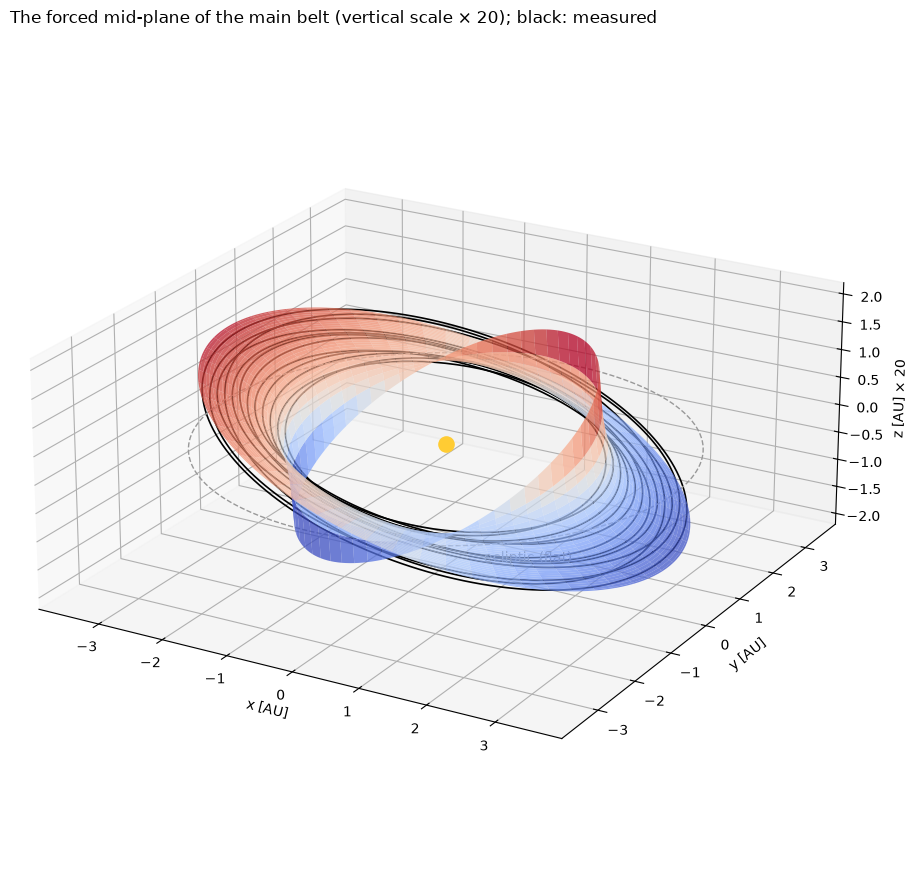

In [11]:
EXAGGERATION = 20
a_s = np.linspace(2.05, 3.3, 60)
lam = np.linspace(0, 2 * np.pi, 181)
I_s, O_s, _ = forced_plane(a_s)
A, L = np.meshgrid(a_s, lam, indexing="ij")
X, Y = A * np.cos(L), A * np.sin(L)
Z = EXAGGERATION * A * np.sin(np.radians(I_s))[:, None] * np.sin(L - np.radians(O_s)[:, None])

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X, Y, Z, facecolors=plt.cm.coolwarm((Z - Z.min()) / (Z.max() - Z.min())), rstride=2, cstride=3,
                linewidth=0, antialiased=True, alpha=0.75, shade=False)
for r in binned[1:]:                                    # measured rings, 2.1-3.3 AU
    ac = 0.5 * (r["lo"] + r["hi"])
    z_ring = EXAGGERATION * ac * np.sin(np.radians(r["I"])) * np.sin(lam - np.radians(r["O"]))
    ax.plot(ac * np.cos(lam), ac * np.sin(lam), z_ring, color="black", lw=1.2)
ax.plot(3.45 * np.cos(lam), 3.45 * np.sin(lam), 0 * lam, color="#999999", lw=1, ls="--")
ax.text(2.4, -3.2, 0, "ecliptic (flat)", color="#777777")
ax.scatter([0], [0], [0], color="#ffcc33", s=120)
ax.set_box_aspect((1, 1, 0.45))
ax.set_zlim(-2.2, 2.2)
ax.view_init(elev=22, azim=-60)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]"); ax.set_zlabel(f"z [AU] × {EXAGGERATION}")
ax.set_title(f"The forced mid-plane of the main belt (vertical scale × {EXAGGERATION}); black: measured", loc="left")
plt.tight_layout(); plt.show()

# Summary

In this tutorial we:

1. **Selected a fair sample** of about 75,000 main-belt asteroids from `MPCORB.DAT`: the paper's orbital cuts, a completeness cut at H < 15.5, and removal of collisional family members using the AstDyS-2 family classification
2. **Measured the belt's mean plane** by averaging orbit poles, with a bootstrap uncertainty following the paper's recipe, and reproduced Cambioni & Malhotra's result to within about one standard error
3. **Built Laplace–Lagrange secular theory from scratch** — the planets' secular matrix, its eigenmodes, and the forced plane of a test particle — and recovered the published planetary nodal frequencies
4. **Confirmed the warped mid-plane**: measured in 0.1 AU bins, the belt's mean plane follows the forced plane over most of the belt, with the ν₁₆ warp near the inner edge and the same small discrepancies the paper found
5. **Drew the warp in 3-D**

### Ideas to extend

- Compute the mean pole separately for the large families removed in Step 2: each should scatter around the local forced plane, with the youngest families (whose nodes have not yet randomized) as the exceptions
- Repeat the binned measurement in finer bins with fainter magnitude cuts as the catalogue grows, to test the small systematic offset the paper and this notebook both see
- Replace linear secular theory near the inner edge with a direct numerical measurement: integrate a ring of test particles at 2.15 AU with REBOUND and average their inclination vectors

### Further Resources

- [Cambioni & Malhotra (2018), *The Mid-plane of the Main Asteroid Belt*, AJ 155, 143](https://doi.org/10.3847/1538-3881/aaab6b) (open access at [arXiv:1801.08096](https://arxiv.org/abs/1801.08096))
- Murray & Dermott (1999), *Solar System Dynamics*, Cambridge University Press, chapter 7 (Laplace–Lagrange secular theory)
- [Milani et al. (2014), *Asteroid families classification: exploiting very large datasets*, Icarus 239, 46](https://doi.org/10.1016/j.icarus.2014.05.039) and the [AstDyS-2 family pages](https://newton.spacedys.com/astdys/index.php?pc=5)
- [Souami & Souchay (2012), *The solar system's invariable plane*, A&A 543, A133](https://doi.org/10.1051/0004-6361/201219011)
- [Plummer (1916), *Statistics of the minor planets*, MNRAS 76, 378](https://doi.org/10.1093/mnras/76.5.378)
- [MPCORB page](https://minorplanetcenter.net/iau/MPCORB.html) and the [Minor Planet Orbit Format documentation](https://docs.minorplanetcenter.net/mpc-ops-docs/orbits/minor-planet-orbit-format/)
- [Companion tutorial: The Kirkwood Gaps](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_kirkwood/)
- [Companion tutorial: Reference Frames for Solar System Dynamics](https://docs.minorplanetcenter.net/tutorials/notebooks/mpc_tutorial_orbit_frames/)

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).